In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/clone_fraud_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5000, 15)


,account_age_days,followers_count,following_count,profile_completeness,username_similarity,login_frequency,new_device_logins,unique_devices,ip_changes,location_changes,messages_per_day,suspicious_links,transaction_count,transaction_amount,is_fraud
0,890,4052,4856,70,0.89,4,1,5,1,1,23,1,6,1759.95,1
1,1324,2585,277,100,0.12,5,0,4,2,2,22,1,2,379.78,0
2,1160,6764,579,93,0.71,7,0,1,0,1,20,1,5,3927.15,0
3,1125,1591,2566,90,0.35,7,1,2,3,1,9,1,4,204.47,0
4,1668,1996,1983,41,0.10,3,2,2,1,0,25,1,3,3098.53,0


In [3]:
df.isnull().sum()

account_age_days        0
followers_count         0
following_count         0
profile_completeness    0
username_similarity     0
login_frequency         0
new_device_logins       0
unique_devices          0
ip_changes              0
location_changes        0
messages_per_day        0
suspicious_links        0
transaction_count       0
transaction_amount      0
is_fraud                0
dtype: int64

In [4]:
df.dtypes

account_age_days          int64
followers_count           int64
following_count           int64
profile_completeness      int64
username_similarity     float64
login_frequency           int64
new_device_logins         int64
unique_devices            int64
ip_changes                int64
location_changes          int64
messages_per_day          int64
suspicious_links          int64
transaction_count         int64
transaction_amount      float64
is_fraud                  int64
dtype: object

In [5]:
df["is_fraud"].value_counts()

is_fraud
0    4231
1     769
Name: count, dtype: int64

In [6]:
df["is_fraud"].value_counts(normalize=True).mul(100).round(2)

is_fraud
0    84.62
1    15.38
Name: proportion, dtype: float64

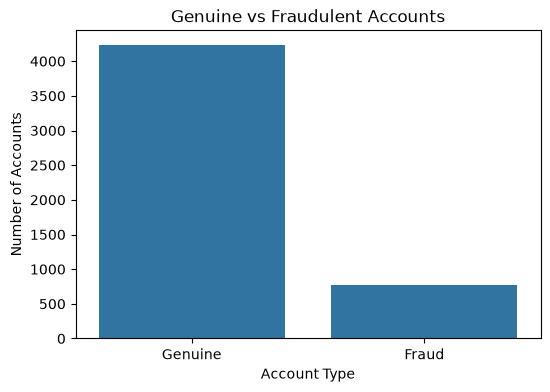

In [7]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="is_fraud")

plt.title("Genuine vs Fraudulent Accounts")
plt.xlabel("Account Type")
plt.ylabel("Number of Accounts")
plt.xticks([0, 1], ["Genuine", "Fraud"])

plt.show()

In [8]:
df.groupby("is_fraud")[
    [
        "username_similarity",
        "new_device_logins",
        "unique_devices",
        "ip_changes",
        "location_changes",
        "suspicious_links",
        "transaction_count",
        "transaction_amount"
    ]
].mean().round(2)

,username_similarity,new_device_logins,unique_devices,ip_changes,location_changes,suspicious_links,transaction_count,transaction_amount
is_fraud,,,,,,,,
0,0.46,0.94,2.85,1.93,0.99,0.93,2.96,1859.36
1,0.71,1.42,3.83,2.30,1.05,1.39,3.14,2649.54


In [9]:
df.groupby("is_fraud")[
    [
        "location_changes",
        "suspicious_links",
        "transaction_count",
        "transaction_amount"
    ]
].mean().round(2)

,location_changes,suspicious_links,transaction_count,transaction_amount
is_fraud,,,,
0,0.99,0.93,2.96,1859.36
1,1.05,1.39,3.14,2649.54


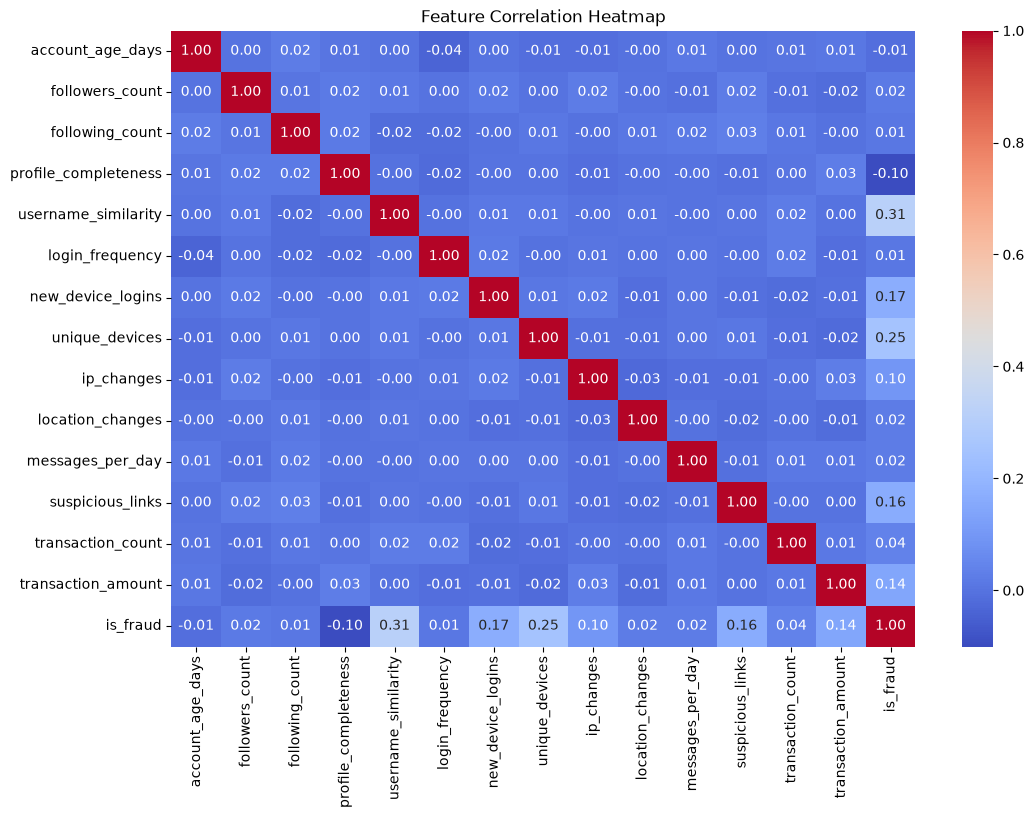

In [10]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()


In [11]:
from sklearn.model_selection import train_test_split

X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4000, 14)
Testing data: (1000, 14)


In [12]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [13]:
y_pred = model.predict(X_test)

print("Predictions completed!")
print(y_pred[:20])

Predictions completed!
[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")
print(f"F1 Score : {f1:.2f}")

Accuracy : 0.92
Precision: 0.81
Recall   : 0.63
F1 Score : 0.71


[[823  23]
 [ 57  97]]


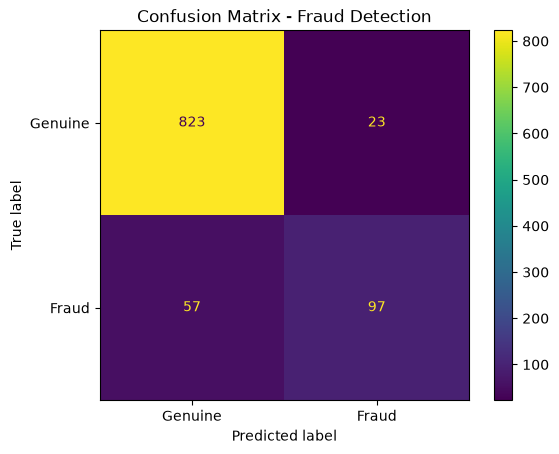

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine", "Fraud"]
)

disp.plot()
plt.title("Confusion Matrix - Fraud Detection")
plt.show()

In [16]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

username_similarity     0.290515
unique_devices          0.120190
transaction_amount      0.095466
suspicious_links        0.076300
profile_completeness    0.067363
ip_changes              0.053108
new_device_logins       0.052991
following_count         0.045170
followers_count         0.044502
account_age_days        0.041599
messages_per_day        0.034740
transaction_count       0.029557
login_frequency         0.025866
location_changes        0.022632
dtype: float64


In [17]:
import joblib

joblib.dump(model, "models/fraud_detection_model.pkl")

print("Model saved successfully!")

FileNotFoundError: [Errno 2] No such file or directory: 'models/fraud_detection_model.pkl'

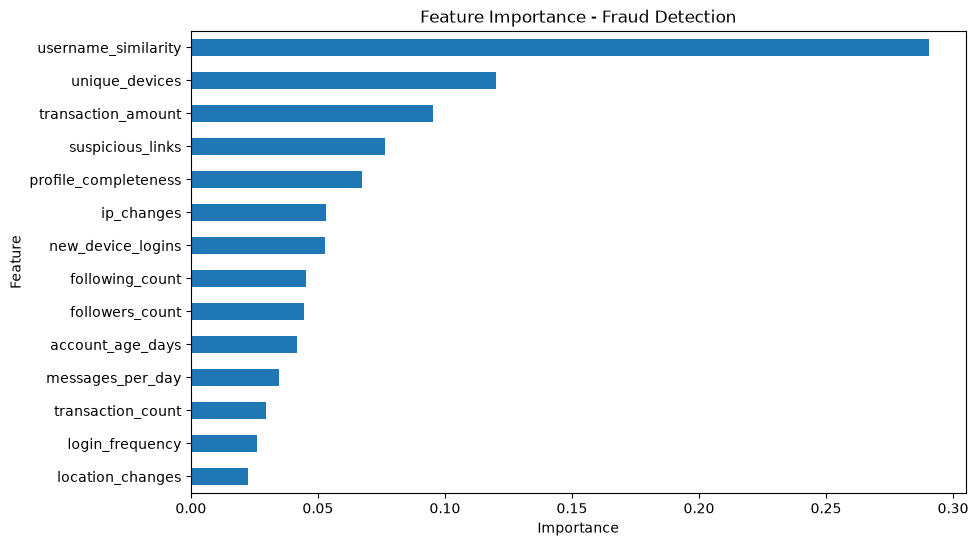

In [18]:
plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(kind="barh")

plt.title("Feature Importance - Fraud Detection")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [19]:
import joblib

joblib.dump(model, "models/fraud_detection_model.pkl")

print("Model saved successfully!")

FileNotFoundError: [Errno 2] No such file or directory: 'models/fraud_detection_model.pkl'

In [20]:
import os

print(os.path.exists("models/fraud_detection_model.pkl"))

False


In [21]:
import os

print(os.getcwd())

c:\Users\hp\Documents\GitHub\clone-account-fraud-detection\notebooks


In [22]:
import joblib

joblib.dump(model, "../models/fraud_detection_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [23]:
import os

print(os.path.exists("../models/fraud_detection_model.pkl"))

True


In [24]:
import joblib

saved_model = joblib.load("../models/fraud_detection_model.pkl")

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [25]:
new_account = pd.DataFrame([{
    "account_age_days": 500,
    "followers_count": 1200,
    "following_count": 800,
    "profile_completeness": 45,
    "username_similarity": 0.92,
    "login_frequency": 8,
    "new_device_logins": 4,
    "unique_devices": 5,
    "ip_changes": 6,
    "location_changes": 4,
    "messages_per_day": 25,
    "suspicious_links": 4,
    "transaction_count": 9,
    "transaction_amount": 7500
}])

prediction = saved_model.predict(new_account)[0]

if prediction == 1:
    print("🚨 Prediction: FRAUDULENT ACCOUNT")
else:
    print("✅ Prediction: GENUINE ACCOUNT")

🚨 Prediction: FRAUDULENT ACCOUNT


In [26]:
probability = saved_model.predict_proba(new_account)[0][1]

print(f"Fraud Probability: {probability * 100:.2f}%")

if probability >= 0.70:
    print("Risk Level: HIGH")
elif probability >= 0.40:
    print("Risk Level: MEDIUM")
else:
    print("Risk Level: LOW")

Fraud Probability: 86.00%
Risk Level: HIGH


In [27]:
genuine_account = pd.DataFrame([{
    "account_age_days": 1200,
    "followers_count": 2500,
    "following_count": 400,
    "profile_completeness": 90,
    "username_similarity": 0.20,
    "login_frequency": 5,
    "new_device_logins": 0,
    "unique_devices": 2,
    "ip_changes": 1,
    "location_changes": 1,
    "messages_per_day": 18,
    "suspicious_links": 0,
    "transaction_count": 3,
    "transaction_amount": 800
}])

prediction = saved_model.predict(genuine_account)[0]
probability = saved_model.predict_proba(genuine_account)[0][1]

print("Prediction:", "FRAUD" if prediction == 1 else "GENUINE")
print(f"Fraud Probability: {probability * 100:.2f}%")

Prediction: GENUINE
Fraud Probability: 0.00%
